In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [135]:
task_time = 45 #task時間 (min)
numberofraw = task_time * 60 * 1000
binPath = "F:/eLacco/Adra1aKO/KO saline ip airpuff/Adra1aKO1_airpuff_saline_ver2.bin"

with open(binPath, "rb") as f:
    data = f.read()
    raw_data = np.frombuffer(data, dtype=np.float64)
    raw_data = raw_data.reshape(-1, 4)
    
if len(raw_data) > numberofraw:
    raw_data = raw_data[:numberofraw]
    #[isosbestic_trigger, green_trigger, flo_data]
    original_time = [(i+1)/1000 for i in range (len(raw_data))] # to second
    iso_trigger = raw_data[:, 0]
    green_trigger = raw_data[:, 1]
    flo_data = raw_data[:, 2] #405nm, 465nmが含まれる

print("データ数：{}, タスク時間：{}分".format(len(raw_data), original_time[-1]/60))

データ数：2700000, タスク時間：45.0分


In [136]:
iso_trigger_LociSeq = []
green_trigger_LociSeq = []
trigger_threshold = 4
count_num = 0
#励起光が20msecのとき
trigger_on_start_point = 2
trigger_on_end_point = 19

#Greenあるいはisosbesticの励起光が照射されているときが1
#励起光がonの終始2msecはノイズがあるので除外（0にする）
for iso_num in range(len(iso_trigger)):
    if iso_trigger[iso_num] >= trigger_threshold:
      count_num += 1
      if trigger_on_start_point < count_num < trigger_on_end_point:
        iso_trigger_LociSeq.append(1)
      else:
        iso_trigger_LociSeq.append(0)
    else:
      count_num = 0
      iso_trigger_LociSeq.append(0)

for g_num in range(len(green_trigger)):
    if green_trigger[g_num] >= trigger_threshold:
      count_num += 1
      if trigger_on_start_point < count_num < trigger_on_end_point:
        green_trigger_LociSeq.append(1)
      else:
        green_trigger_LociSeq.append(0)
    else:
      count_num = 0
      green_trigger_LociSeq.append(0)
        
#numpyに変換
iso_trigger_LociSeq = np.array(iso_trigger_LociSeq)
green_trigger_LociSeq = np.array(green_trigger_LociSeq)


#差分をとり1だったら励起光開始、-1だったら励起光終了
#開始と終了のインデックスを取得
iso_diff = np.diff(iso_trigger_LociSeq)
iso_start_index = [np.where(iso_diff == 1)[0] + 1][0]
iso_end_index = [np.where(iso_diff == -1)[0] + 1][0]

green_diff = np.diff(green_trigger_LociSeq)
green_start_index = [np.where(green_diff == 1)[0] + 1][0]
green_end_index = [np.where(green_diff == -1)[0] + 1][0]

In [137]:
#バグを取り除く
if green_start_index[0] - green_end_index[0] > 0:
  green_end_index = green_end_index[1:]
elif iso_start_index[0] - iso_end_index[0] > 0:
  iso_end_index = iso_end_index[1:]

if green_start_index[-1] - green_end_index[-1] > 0:
  green_start_index = green_start_index[:-1]
elif iso_start_index[-1] - iso_end_index[-1] > 0:
  iso_start_index = iso_start_index[:-1]

if len(iso_start_index) > len(green_start_index):
  iso_start_index = iso_start_index[1:]
  iso_end_index = iso_end_index[1:]
elif len(iso_start_index) < len(green_start_index):
  green_start_index = green_start_index[1:]
  green_end_index = green_end_index[1:]

In [138]:
iso_20Hz = []
green_20Hz = []
iso_20Hz_time = []
green_20Hz_time = []

#ひと塊の励起光の照射時の蛍光、時間の平均を算出
try:
  for i in range(len(iso_start_index)):
    iso_20Hz.append(np.mean(flo_data[iso_start_index[i]:iso_end_index[i]]))
    iso_20Hz_time.append(np.mean(original_time[iso_start_index[i]:iso_end_index[i]]))
except IndexError:
  pass

try:
  for i in range(len(green_start_index)):
    green_20Hz.append(np.mean(flo_data[green_start_index[i]:green_end_index[i]]))
    green_20Hz_time.append(np.mean(original_time[green_start_index[i]:green_end_index[i]]))
except IndexError:
  pass

#405と465のデータの数を一緒にする
if len(iso_20Hz) < len(green_20Hz):
  green_mean = green_20Hz[:len(iso_20Hz)]
  green_20Hz_time = green_20Hz_time[:len(iso_20Hz)]

In [139]:
#移動平均
num_conv = np.ones(20)/ 20
nomalized_iso = np.convolve(iso_20Hz, num_conv, mode="same")
nomalized_green = np.convolve(green_20Hz, num_conv, mode="same")

#時間のリストを作成(0.05秒間隔)
time_list = [i*0.05 for i in range(1, len(nomalized_iso)+1, 1)]

In [140]:
nomalized_flot = []
nomalized_flot.append(time_list)
nomalized_flot.append(nomalized_iso)
nomalized_flot.append(nomalized_green)

df = pd.DataFrame(nomalized_flot, index=["Time", "iso", "green"]).T
df.to_excel("Adra1aKO1_airpuff_saline.xlsx")

In [141]:
def idx_of_the_nearest(data, value):
  '''
  一番近いインデックスを取得
  '''
  idx = np.argmin(np.abs(np.array(data) - value))

  return idx

In [142]:
BC_ind = idx_of_the_nearest(time_list, 2700)

start_BL_ind = idx_of_the_nearest(time_list, 0)
end_BL_ind = idx_of_the_nearest(time_list, 50)

In [143]:
iso = [float(_) for _ in np.array(nomalized_iso[10:-9])]
green = [float(_) for _ in np.array(nomalized_green[10:-9])]
add1 = [1 for i in range(len(nomalized_green[10:-9]))]
time = time_list[10:-9]

fit = np.polyfit(time[:], iso[:], 1)
fitted_iso = fit[0] * np.array(time) + fit[1]
isoBC = iso - fitted_iso
isoBCN = isoBC + add1

fit = np.polyfit(time[:BC_ind], green[:BC_ind], 1)
fitted_green = fit[0] * np.array(time) + fit[1]
greenBC = green - fitted_green
greenBCN = greenBC + add1

BL_mean = np.mean(greenBCN[start_BL_ind:end_BL_ind] / isoBCN[start_BL_ind:end_BL_ind])
dFF = greenBCN / isoBCN - BL_mean

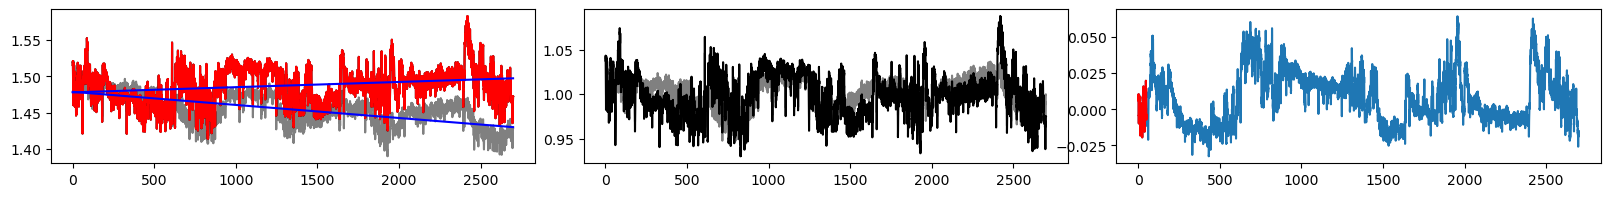

In [144]:
plt.figure(figsize=(20, 2))
plt.subplots_adjust(wspace=0.1, hspace=0.4)

plt.subplot(1, 3, 1)
plt.plot(time, iso, color="gray")
plt.plot(time, green, color="black")

#plt.xticks([0, 600,1200,1800,2400,3000])


plt.plot(time[:BC_ind], green[:BC_ind], color="red")

plt.plot(time, fitted_iso, color="blue")
plt.plot(time, fitted_green, color="blue")

plt.subplot(1, 3, 2)
plt.plot(time, isoBCN, color="gray")
plt.plot(time, greenBCN, color="black")
#plt.xticks([0, 600,1200,1800,2400,3000])
#plt.ylim(0.8, 1.3)

plt.subplot(1, 3, 3)
plt.plot(time, dFF)
plt.plot(time[start_BL_ind:end_BL_ind], dFF[start_BL_ind:end_BL_ind], color='red')
#plt.ylim(0.015, 0.06)
#plt.xticks([0, 600,1200,1800,2400,3000])
plt.show()